<a href="https://colab.research.google.com/github/uu-sml/wasp-assigninmen-af-classification/blob/main/assignment_ecg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comment out cell below to use the old model.

In [1]:
import os
file_path = 'model.pth'

if os.path.exists(file_path):
    os.remove(file_path)
    print(f"Successfully deleted {file_path}")
else:
    print(f"File {file_path} does not exist.")

File model.pth does not exist.


In [2]:
import os

# helper function
def exists(path):
    val = os.path.exists(path)
    if val:
        print(f'{path} already exits. Using cached. Delete it manually to recieve it again!')
    return val

# Force clone requirements.txt to ensure it's fresh and present
if exists('requirements.txt'):
    !rm requirements.txt
!git clone https://gist.github.com/dgedon/8a7b91714568dc35d0527233e9ceada4.git req
!mv req/requirements.txt .
!yes | rm -r req

# Read requirements.txt and remove all version constraints
with open('requirements.txt', 'r') as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    # Remove '==' and everything after it
    if '==' in line:
        package_name = line.split('==')[0]
        new_lines.append(package_name + '\n')
    else:
        new_lines.append(line)

# Write back to requirements.txt
with open('requirements.txt', 'w') as f:
    f.writelines(new_lines)

print("Modified requirements.txt: removed all version constraints.")

requirements.txt already exits. Using cached. Delete it manually to recieve it again!


'rm' is not recognized as an internal or external command,
operable program or batch file.
fatal: destination path 'req' already exists and is not an empty directory.
'mv' is not recognized as an internal or external command,
operable program or batch file.


Modified requirements.txt: removed all version constraints.


'yes' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# Install packages (python>=3.9 is required)
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
#from tqdm.auto import trange, tqdm
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import ast
from PIL import Image
import glob
%matplotlib inline

In [5]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))
    x = torch.randn(2, 2).to("cuda")
    print("Tensor device:", x.device)

CUDA available: True
Device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 2060
Tensor device: cuda:0


Using large dataset...
Division of test data vs train data: 0.1275
2000
255
1745
Files created successfully
(255, 5)
(255, 185, 330)
(1745, 5)
(1745, 185, 330)


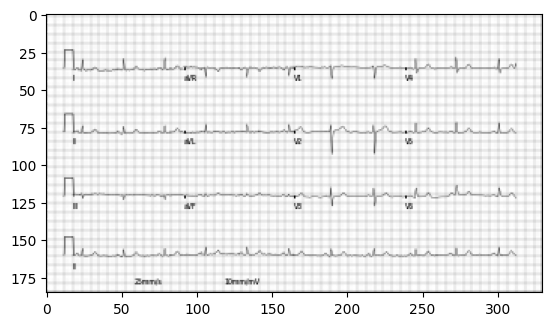

In [6]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

set_data = 'L' # L = large, S = small
classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

if set_data == 'S':
    h5_names = ['test_s.h5', 'train_s.h5']
else:
    h5_names = ['test_l.h5', 'train_l.h5']

try:
    f1 = h5py.File(h5_names[0], 'r')
    f2 = h5py.File(h5_names[1], 'r')
    print('Files exist')
except FileNotFoundError:

    path = r'..\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\'
    sampling_rate=100

    # load and convert annotation data
    Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
    Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

    # Load raw signal data
    #X = load_raw_data(Y, sampling_rate, path)

    # Load scp_statements.csv for diagnostic aggregation
    agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1]

    def aggregate_diagnostic(y_dic):
        tmp = []
        for key in y_dic.keys():
            if key in agg_df.index:
                tmp.append(agg_df.loc[key].diagnostic_class)
        return list(set(tmp))

    # Apply diagnostic superclass
    Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

    # Split data into train and test
    test_fold = 10
    # Train
    #X_train = X[np.where(Y.strat_fold != test_fold)]
    y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
    # Test
    #X_test = X[np.where(Y.strat_fold == test_fold)]
    y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

    png_folder_path = r"..\output-images" + "\\"
    png_paths = sorted(glob.glob(png_folder_path + "*.png"))

    arrays_train = []
    arrays_test = []
    png_paths_test = [x for x in png_paths if int(x.split('\\')[-1].split('_')[0]) in y_test.index.tolist()]
    png_paths_train = [x for x in png_paths if int(x.split('\\')[-1].split('_')[0]) in y_train.index.tolist()]
    
    data_size = 0
    if set_data == 'S':
        data_size = 1000
        print('Using small dataset...')
    elif set_data == 'L':
        data_size = len(png_paths)
        print('Using large dataset...')
    else:
        print('Error: No dataset specified')
        raise SystemExit  # Stops execution
        
    ratio = len(png_paths_test)/len(png_paths)
    print(f'Division of test data vs train data: {ratio}')
    data_size_test = int(ratio*data_size)
    data_size_train = data_size - data_size_test
    png_paths_test = png_paths_test[:data_size_test]
    png_paths_train = png_paths_train[:data_size_train]
    
    print(data_size)
    print(data_size_test)
    print(data_size_train)

    for p in png_paths_test:
        img = Image.open(p).convert("L")
        arrays_test.append(np.array(img))

    for p in png_paths_train:
        img = Image.open(p).convert("L")
        arrays_train.append(np.array(img))

    arrays_test = np.stack(arrays_test)
    arrays_train = np.stack(arrays_train)

    arrays_test = arrays_test / 255
    arrays_train = arrays_train / 255
    
    H = arrays_train.shape[1]
    arrays_test = arrays_test[:,int(0.275*H):,:]
    arrays_train = arrays_train[:,int(0.275*H):,:]
    
    y_test = y_test.iloc[0:].to_list()
    y_train = y_train.iloc[0:].to_list()

    for i in range(len(y_test)):
        lst = np.zeros(len(classes))
        z = 0
        for j in classes:
            if j in y_test[i]:
                lst[z] = 1
            z+=1
        y_test[i] = lst

    for i in range(len(y_train)):
        lst = np.zeros(len(classes))
        z = 0
        for j in classes:
            if j in y_train[i]:
                lst[z] = 1
            z+=1
        y_train[i] = lst

    y_test = np.stack(y_test)
    y_train = np.stack(y_train)

    y_test = y_test[:arrays_test.shape[0]]
    y_train = y_train[:arrays_train.shape[0]]

    with h5py.File(h5_names[0], "w") as h5f_test:
        h5f_test.create_dataset("images", data=arrays_test, compression="gzip")
        h5f_test.create_dataset("labels", data=y_test, compression='gzip')

    with h5py.File(h5_names[1], "w") as h5f_train:
        h5f_train.create_dataset("images", data=arrays_train, compression="gzip")
        h5f_train.create_dataset("labels", data=y_train, compression='gzip')

    print("Files created successfully")

    print(y_test.shape)
    print(arrays_test.shape)
    print(y_train.shape)
    print(arrays_train.shape)
    
    plt.imshow(arrays_train[0], cmap='gray')
    plt.show()

In [6]:
# Path to the training CSV file
path_to_csv_train = r'..\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv'

# Load the CSV file into a DataFrame
df_train_labels = pd.read_csv(path_to_csv_train)
'''
print("\nDistribution of AF (Atrial Fibrillation) labels:")
display(df_train_labels['AF'].value_counts())
'''
# 0 = male, 1 = female
print("\nDistribution of Sex:")
display(df_train_labels['sex'].value_counts())

print("\nDistribution of Age:")
display(df_train_labels['age'].describe())


Distribution of Sex:


sex
0    11354
1    10445
Name: count, dtype: int64


Distribution of Age:


count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

### Coding Task 2: Define your model

In the cell below you have to define your model. You can be inspired by the baseline model above but you can also define any other kind of neural network architecture.

In [7]:
# VGG-16

class Model(nn.Module):
    def __init__(self,):
        super(Model, self).__init__()
        self.kernel_size = 3
        
        self.input_dim = (dimensions[0], dimensions[1]) #(425, 550) right now
        self.output_dim = len(classes)

        initial_in_channels = 1 #Before it was 8 due to the number of leads. But now it's just one channel for the image.
        h_dim = self.input_dim[0]
        w_dim = self.input_dim[1]
        out_dim = self.output_dim
        
        #https://www.geeksforgeeks.org/machine-learning/ml-getting-started-with-alexnet/
        
        self.conv1_1 = nn.Sequential(
            nn.Conv2d(  in_channels= initial_in_channels,
                        out_channels= 64,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.conv1_2 = nn.Sequential(
            nn.Conv2d(  in_channels= 64,
                        out_channels= 64,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2_1 = nn.Sequential(
            nn.Conv2d(  in_channels= 64,
                        out_channels= 128,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.conv2_2 = nn.Sequential(
            nn.Conv2d(  in_channels= 128,
                        out_channels= 128,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3_1 = nn.Sequential(
            nn.Conv2d(  in_channels= 128,
                        out_channels= 256,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        self.conv3_2 = nn.Sequential(
            nn.Conv2d(  in_channels= 256,
                        out_channels= 256,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        self.conv3_3 = nn.Sequential(
            nn.Conv2d(  in_channels= 256,
                        out_channels= 256,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4_1 = nn.Sequential(
            nn.Conv2d(  in_channels= 256,
                        out_channels= 512,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.conv4_2 = nn.Sequential(
            nn.Conv2d(  in_channels= 512,
                        out_channels= 512,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.conv4_3 = nn.Sequential(
            nn.Conv2d(  in_channels= 512,
                        out_channels= 512,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv5_1 = nn.Sequential(
            nn.Conv2d(  in_channels= 512,
                        out_channels= 512,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.conv5_2 = nn.Sequential(
            nn.Conv2d(  in_channels= 512,
                        out_channels= 512,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.conv5_3 = nn.Sequential(
            nn.Conv2d(  in_channels= 512,
                        out_channels= 512,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.dense1 = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(  in_features=5*10*512,
                        out_features=4096),
            nn.ReLU() 
        )
        
        self.dense2 = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(  in_features=4096,
                        out_features=4096),
            nn.ReLU() 
        )
        
        self.dense3 = nn.Sequential(
            nn.Linear(  in_features=4096,
                        out_features=out_dim)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        
        x = self.conv1_1(x)
        x = self.conv1_2(x)
        x = self.pool1(x)
        
        x = self.conv2_1(x)
        x = self.conv2_2(x)
        x = self.pool2(x)
        
        x = self.conv3_1(x)
        x = self.conv3_2(x)
        x = self.conv3_3(x)
        x = self.pool3(x)
        
        x = self.conv4_1(x)
        x = self.conv4_2(x)
        x = self.conv4_3(x)
        x = self.pool4(x)
        
        x = self.conv5_1(x)
        x = self.conv5_2(x)
        x = self.conv5_3(x)
        x = self.pool5(x)
        # print(x.shape) # Observe output dimensions
        
        x_flat = x.view(x.size(0), -1)
        x = self.dense1(x_flat)
        x = self.dense2(x)
        x = self.dense3(x)

        return x


In [8]:
# AlexNet
'''
class Model(nn.Module):
    def __init__(self,):
        super(Model, self).__init__()
        self.kernel_size = 3
        
        self.input_dim = (dimensions[0], dimensions[1]) #(425, 550) right now
        self.output_dim = len(classes)

        initial_in_channels = 1 #Before it was 8 due to the number of leads. But now it's just one channel for the image.
        h_dim = self.input_dim[0]
        w_dim = self.input_dim[1]
        out_dim = self.output_dim
        
        #https://www.geeksforgeeks.org/machine-learning/ml-getting-started-with-alexnet/
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(  in_channels= initial_in_channels,
                        out_channels= 96,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(96)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(  in_channels= 96,
                        out_channels= 256,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(256)
        )
        
        self.layer3 = nn.Sequential(
            nn.Conv2d(  in_channels= 256,
                        out_channels= 384,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.ReLU()
        )
        
        self.layer4 = nn.Sequential(
            nn.Conv2d(  in_channels= 384,
                        out_channels= 384,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.ReLU()
        )
        
        self.layer5 = nn.Sequential(
            nn.Conv2d(  in_channels= 384,
                        out_channels= 256,
                        kernel_size= self.kernel_size,
                        stride= 1,
                        padding= 1
                        ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.dense1 = nn.Sequential(
            nn.Linear(  in_features=53*68*256,
                        out_features=1024),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        self.dense2 = nn.Sequential(
            nn.Linear(  in_features=1024,
                        out_features=512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        self.dense3 = nn.Sequential(
            nn.Linear(  in_features=512,
                        out_features=5)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        
        x_flat = x.view(x.size(0), -1)
        x = self.dense1(x_flat)
        x = self.dense2(x)
        x = self.dense3(x)

        return x
'''

"\nclass Model(nn.Module):\n    def __init__(self,):\n        super(Model, self).__init__()\n        self.kernel_size = 3\n        \n        self.input_dim = (dimensions[0], dimensions[1]) #(425, 550) right now\n        self.output_dim = len(classes)\n\n        initial_in_channels = 1 #Before it was 8 due to the number of leads. But now it's just one channel for the image.\n        h_dim = self.input_dim[0]\n        w_dim = self.input_dim[1]\n        out_dim = self.output_dim\n        \n        #https://www.geeksforgeeks.org/machine-learning/ml-getting-started-with-alexnet/\n        \n        self.layer1 = nn.Sequential(\n            nn.Conv2d(  in_channels= initial_in_channels,\n                        out_channels= 96,\n                        kernel_size= self.kernel_size,\n                        stride= 1,\n                        padding= 1\n                        ),\n            nn.ReLU(),\n            nn.MaxPool2d(kernel_size=2, stride=2),\n            nn.BatchNorm2d(96)\n    

---
## Train function

The function `train(...)` is called to in every epoch to train the model. The function loads the training data, makes predictions, compares predictions with true labels in the loss function and adapting the model parameters using stochastic gradient descent.

In the code cell below there is the basic structure to load data from the data loader and to log your loss. The arguments of the function are explained by the use in the `main(...)` function below.

If you are unfamiliar with PyTorch training loops, then this official [tutorial](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) might help (especially section "4. Train your Network").

In [9]:
def train_loop(epoch, dataloader, model, optimizer, loss_function, device):
    # model to training mode (important to correctly handle dropout or batchnorm layers)
    model.train()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    # progress bar def
    train_pbar = tqdm(dataloader, desc="Training Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # training loop
    for images, labels in train_pbar:
        # data to device (CPU or GPU if available)
        images, labels = images.to(device), labels.to(device)

        """
        TASK: Insert your code here. This task can be done in 5 lines of code.
        """
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(images)

        # Update progress bar
        train_pbar.set_postfix({'loss': total_loss / n_entries})
    train_pbar.close()
    return total_loss / n_entries

---
## Eval function

The `eval(...)` function is similar to the `train(...)` function but is used to evaluate the model on validation data without adapting the model parameters. You can prohibit computing gradients by using a `with torch.no_grad():` statement.

Currenlty only the loss is logged here. Additionally you have to collect all your predictions and the true values in order to compute more metrics such as AUROC.

### Coding Task 4: Fill evaluation loop
Fill the code cell below such we obtain model predictions to evaluate the validation loss and collect the prediction in order to compute other validation metrics in the `main(...)` function.

In [10]:
def eval_loop(epoch, dataloader, model, loss_function, device):
    # model to evaluation mode (important to correctly handle dropout or batchnorm layers)
    model.eval()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    valid_probs = []  # accumulated predicted probabilities
    valid_true = [] # accumulated true labels

    # progress bar def
    eval_pbar = tqdm(dataloader, desc="Evaluation Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # evaluation loop
    for images_cpu, labels_cpu in eval_pbar:
        # data to device (CPU or GPU if available)
        images, labels = images_cpu.to(device), labels_cpu.to(device)

        """
        TASK: Insert your code here. This task can be done in 6 lines of code.
        """

        with torch.no_grad():
            outputs = model(images)
            loss = loss_function(outputs, labels)
            probabilities = torch.sigmoid(outputs)

        valid_probs.append(probabilities.cpu().numpy())
        valid_true.append(labels.cpu().numpy())

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(images)

        # Update progress bar
        eval_pbar.set_postfix({'loss': total_loss / n_entries})
    eval_pbar.close()
    return total_loss / n_entries, np.vstack(valid_probs), np.vstack(valid_true)

---
## Run Training

In the code cell below there are some initial (non-optimal!) training hyperparameters. Further, we combine everything from above into training code. That means that we build the dataloaders, define the model/loss/optimizer and then train/validate the model over multiple epochs. Here, we save the model with the lowest validation loss as the best model.

In [11]:
# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# choose variables
"""
TASK: Adapt the following hyperparameters if necessary
"""
learning_rate = 1e-3
weight_decay = 1e-3
num_epochs = 10
batch_size = 64

In [12]:
from torch.utils.data import TensorDataset, random_split, DataLoader

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tqdm.write("Use device: {device:}\n".format(device=device))

# =============== Build data loaders ======================================#
tqdm.write("Building data loaders...")

# path_to_h5_train, path_to_csv_train, path_to_records = 'codesubset/train.h5', 'codesubset/train.csv', 'codesubset/train/RECORDS.txt'
# # load traces
# traces = torch.tensor(h5py.File(path_to_h5_train, 'r')['tracings'][()], dtype=torch.float32)
# # load labels
# ids_traces = [int(x.split('TNMG')[1]) for x in list(pd.read_csv(path_to_records, header=None)[0])] # Get order of ids in traces
# df = pd.read_csv(path_to_csv_train)
# df.set_index('id_exam', inplace=True)
# df = df.reindex(ids_traces) # make sure the order is the same
# labels = torch.tensor(np.array(df['AF']), dtype=torch.float32).reshape(-1,1)
if set_data == 'S':
    path_to_h5_train = 'train_s.h5'
else:
    path_to_h5_train = 'train_l.h5'
images = torch.tensor(h5py.File(path_to_h5_train, 'r')['images'][()], dtype=torch.float32)
labels = torch.tensor(h5py.File(path_to_h5_train, 'r')['labels'][()], dtype=torch.float32) #maybe reshape is necessary

dimensions = (images.shape[1], images.shape[2])

# load dataset
dataset = TensorDataset(images, labels)
len_dataset = len(dataset)
n_classes = len(classes)

# split data
"""
TASK: Split the dataset in train and validation; Insert your code here.
This can be done in <=4 line of code
"""

train_size = int(0.8 * len_dataset)
valid_size = len_dataset - train_size
dataset_train, dataset_valid = random_split(dataset, [train_size, valid_size])


# build data loaders
train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=False)
valid_dataloader = DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)
tqdm.write("Done!\n")

Use device: cpu

Building data loaders...
Done!



In [13]:
# =============== Define model ============================================#
tqdm.write("Define model...")
"""
TASK: Replace the baseline model with your model; Insert your code here
"""
model = Model()
model.to(device=device)
tqdm.write("Done!\n")

# =============== Define loss function ====================================#
"""
TASK: define the loss; Insert your code here. This can be done in 1 line of code
"""
'''
# Define weights because imbalance
class_counts = np.array([9514, 5469, 5235, 4898, 2649])
N = np.sum(class_counts)

weights = N / class_counts
weights = weights / np.max(weights) # Normalize
weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Class weights: {weights}')

#weights2 = torch.tensor([1.291, 2.986, 3.164, 3.451, 7.229], dtype=torch.float32).to(device)
weights2 = (N-class_counts) / class_counts
weights2 = weights2 / np.max(weights2) # Normalize
weights2 = torch.tensor(weights2, dtype=torch.float32).to(device)
print(f'Class weights2: {weights2}')
'''

tqdm.write("Define loss function...")
#loss_function = nn.CrossEntropyLoss()
loss_function = nn.BCEWithLogitsLoss()
#loss_function = nn.BCELoss()
tqdm.write("Done!\n")

# =============== Define optimizer ========================================#
tqdm.write("Define optimiser...")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
tqdm.write("Done!\n")

# =============== Define lr scheduler =====================================#
# TODO advanced students (non mandatory)
"""
OPTIONAL: define a learning rate scheduler; Insert your code here
"""
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5,
    verbose=True
)

lr_scheduler = None

Define model...
Done!

Define loss function...
Done!

Define optimiser...
Done!

Adjusting learning rate of group 0 to 1.0000e-03.


In [14]:
# =============== Train model =============================================#
tqdm.write("Training...")
best_loss = np.inf
# allocation
train_loss_all, valid_loss_all = [], []

epoch_list = np.linspace(1, num_epochs, num_epochs)
score_list = []
best_models_list = []
best_score_list = []
# loop over epochs
for epoch in trange(1, num_epochs + 1):
    # training loop
    train_loss = train_loop(epoch, train_dataloader, model, optimizer, loss_function, device)
    # validation loop
    valid_loss, y_pred, y_true = eval_loop(epoch, valid_dataloader, model, loss_function, device)

    # collect losses
    train_loss_all.append(train_loss)
    valid_loss_all.append(valid_loss)

    # compute validation metrics for performance evaluation
    """
    TASK: compute validation metrics (e.g. AUROC); Insert your code here
    This can be done e.g. in 5 lines of code
    """
    from sklearn.metrics import roc_auc_score
    score = roc_auc_score(y_true=y_true, y_score=y_pred, average='macro')
    score_list.append(score)

    # save best model: here we save the model only for the lowest validation loss
    if valid_loss < best_loss:
        # Save model parameters
        torch.save({'model': model.state_dict()}, 'model.pth')
        # Update best validation loss
        best_loss = valid_loss
        # statement
        model_save_state = "Best model -> saved"
        best_models_list.append(epoch)
        best_score_list.append(score)
    else:
        model_save_state = ""

    # Print message
    tqdm.write('Epoch {epoch:2d}: \t'
                'Train Loss {train_loss:.6f} \t'
                'Valid Loss {valid_loss:.6f} \t'
                '{model_save}'
                .format(epoch=epoch,
                        train_loss=train_loss,
                        valid_loss=valid_loss,
                        model_save=model_save_state)
                    )

    # Update learning rate with lr-scheduler
    if lr_scheduler:
        lr_scheduler.step()

Training...


  0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch  1:   0%|          | 0/22 [00:00<?, ?it/s]

Evaluation Epoch  1:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch  1: 	Train Loss 0.053660 	Valid Loss 0.008984 	Best model -> saved


...

Evaluation Epoch  9:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch  9: 	Train Loss 0.005972 	Valid Loss 0.019673 	


Training Epoch 10:   0%|          | 0/22 [00:00<?, ?it/s]

Evaluation Epoch 10:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 10: 	Train Loss 0.005904 	Valid Loss 0.012390 	


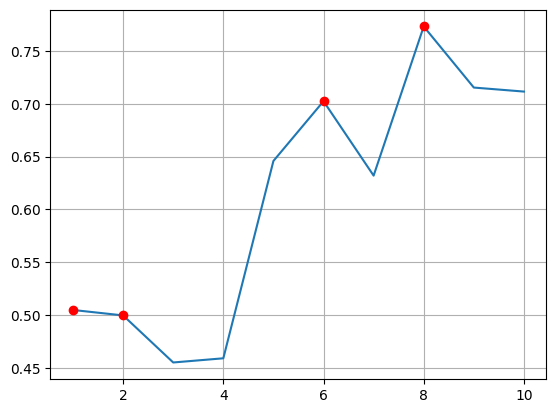

In [15]:
plt.plot(epoch_list, score_list)
plt.plot(best_models_list, best_score_list, 'ro')
plt.grid('on')
plt.show()

---
## Model Testing

Since we saved our best model, we can now load the trained model and make predictions on the test data set. We save the predictions in a csv file which will be uploaded as part of the deliverables. Note that we take a `Sigmoid()` function on the model prediction in order to obtain soft predictions (probabilities) instead of hard predictions (0s or 1s).

In [16]:
# build the dataloader once and re-use when running the cell below possibly multiple times.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =============== Build data loaders ==========================================#
tqdm.write("Building data loaders...")
# load data
if set_data == 'S':
    path_to_h5_test = 'test_s.h5'
else:
    path_to_h5_test = 'test_l.h5'
images_test = torch.tensor(h5py.File(path_to_h5_test, 'r')['images'][()], dtype=torch.float32)
labels_test = torch.tensor(h5py.File(path_to_h5_test, 'r')['labels'][()], dtype=torch.float32)
dataset_test = TensorDataset(images_test, labels_test)
len_dataset_test = len(dataset_test)

# build data loaders
test_dataloader = DataLoader(dataset_test, batch_size=32, shuffle=False)
tqdm.write("Done!\n")

Building data loaders...
Done!



In [17]:
# =============== Define model ================================================#
tqdm.write("Define model...")
"""
TASK: Replace the baseline model with your model; Insert your code here
"""
model = Model()

# load stored model parameters
ckpt = torch.load('model.pth', map_location=lambda storage, loc: storage)
model.load_state_dict(ckpt['model'])
# put model on device
model.to(device=device)
tqdm.write("Done!\n")

# =============== Evaluate on test ==============================================#
model.eval()
# allocation
test_pred = torch.zeros(len_dataset_test,len(classes))
test_true = torch.zeros(len_dataset_test,len(classes))
# progress bar def
test_pbar = tqdm(test_dataloader, desc="Testing")

# evaluation loop
end=0
for traces in test_pbar:
    # data to device
    labels = traces[1].to(device)
    traces = traces[0].to(device)
    start = end

    with torch.no_grad():
        # Forward pass
        model_output = model(traces)

        # store output
        end = min(start + len(model_output), test_pred.shape[0])
        test_pred[start:end] = torch.nn.Sigmoid()(model_output).detach().cpu()
        test_true[start:end] = labels

test_pbar.close()

# =============== Evaluate on validation ==============================================#
model.eval()
# allocation
valid_pred = torch.zeros(valid_size,len(classes))
valid_true = torch.zeros(valid_size,len(classes))

# progress bar def
valid_pbar = tqdm(valid_dataloader, desc="Validating")

# evaluation loop
end=0
for traces in valid_pbar:
    # data to device
    labels = traces[1].to(device)
    traces = traces[0].to(device)
    start = end
    
    with torch.no_grad():
        # Forward pass
        model_output = model(traces)

        # store output
        end = min(start + len(model_output), valid_pred.shape[0])
        valid_pred[start:end] = torch.nn.Sigmoid()(model_output).detach().cpu()
        valid_true[start:end] = labels

valid_pbar.close()

# =============== Save predictions ============================================#
# Only binary
# soft_pred = np.stack((1-test_pred.numpy(), test_pred.numpy()),axis=1).squeeze()

Define model...
Done!



Testing:   0%|          | 0/8 [00:00<?, ?it/s]

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

In [1]:
'''
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score 

# Use validation set y_true and y_pred to optimize thresholds
n_classes = len(classes)
optimal_thresholds = np.zeros(n_classes)
th_list = np.linspace(0.01, 0.99, 100)

print(f'Optimal thresholds:')
for class_i in range(n_classes):
    best_f1 = 0
    best_th = 0.5
    
    for th in th_list:
        class_predictions = (valid_pred[:, class_i] >= th).astype(int)
        class_f1 = f1_score(valid_true[:, class_i], class_predictions)
        
        if class_f1 > best_f1:
            best_f1 = class_f1
            best_th = th
    
    optimal_thresholds[class_i] = best_th
    print(f'{classes[class_i]}: {best_th:.2f}')

# Use test set test_true and test_pred to validate model
predictions = np.zeros_like(test_pred)
for class_i in range(n_classes):
    predictions[:, class_i] = (test_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy
micro_auroc = roc_auc_score(test_true, predictions, average='micro')
macro_auroc = roc_auc_score(test_true, predictions, average='macro')
micro_f1 = f1_score(test_true, predictions, average='micro')
macro_f1 = f1_score(test_true, predictions, average='macro')

print(f"\nOverall Metrics:")
print(f"Micro Auroc: {micro_auroc:.4f}")
print(f"Macro Auroc: {macro_auroc:.4f}")
print(f"Micro F1-score: {micro_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}\n")

for i in range(10):
    print(f'{predictions[i]} = {test_true[i]} = {test_pred[i]}')
'''

Optimal thresholds:
NORM: 0.80
MI: 0.05
STTC: 0.09
CD: 0.11
HYP: 0.08

Overall Metrics:
Micro Auroc: 0.5883
Macro Auroc: 0.6707
Micro F1-score: 0.4221
Macro F1-score: 0.4339

[0. 1. 0. 0. 0.] = [1. 0. 0. 0. 0.] = [0.7876813  0.08025856 0.05571676 0.09760474 0.00976735]
[0. 1. 0. 0. 0.] = [1. 0. 0. 0. 0.] = [0.7503591  0.11182845 0.08550444 0.07986291 0.01531376]
[0. 1. 1. 1. 0.] = [1. 0. 0. 0. 0.] = [0.6117884  0.18282734 0.13032259 0.17386316 0.04245914]
[1. 1. 0. 0. 0.] = [1. 0. 0. 0. 0.] = [0.87066984 0.05227234 0.04118767 0.05247132 0.00535201]
[1. 1. 0. 0. 0.] = [1. 0. 0. 0. 0.] = [0.8241635  0.07451101 0.05812405 0.07965885 0.0132841 ]
[0. 1. 0. 0. 0.] = [0. 1. 0. 0. 0.] = [0.7912776  0.08138485 0.06793939 0.0538878  0.00799466]
[1. 1. 0. 0. 0.] = [0. 0. 0. 1. 0.] = [0.82274115 0.06849951 0.04909606 0.08886549 0.00900714]
[1. 1. 0. 0. 0.] = [1. 0. 0. 0. 0.] = [0.84492344 0.06127327 0.04539255 0.0718307  0.00705715]
[1. 1. 0. 0. 0.] = [1. 0. 0. 0. 0.] = [0.8199565  0.07874094 0.05

In [19]:

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Predictions for validation and test
if type(test_pred)!= np.ndarray:
    test_pred = test_pred.detach().cpu().numpy()
if type(test_true)!= np.ndarray:
    test_true = test_true.detach().cpu().numpy()
if type(valid_pred)!= np.ndarray:
    valid_pred = valid_pred.detach().cpu().numpy()
if type(valid_true)!= np.ndarray:
    valid_true = valid_true.detach().cpu().numpy()

test_bin_pred = (test_pred >= 0.5).astype(int)
valid_bin_pred = (valid_pred >= 0.5).astype(int)



# with h5py.File('signal_test_s.h5', 'r') as f:
#     test_true = f['labels'][:]       # or np.array(f['labels'])



# for i in range(10):
#     print(f'{valid_bin_pred[i]} = {valid_true[i]} = {valid_pred[i]}')


# Calculate accuracy on Validation
micro_auroc = roc_auc_score(valid_true, valid_pred, average='micro')
macro_auroc = roc_auc_score(valid_true, valid_pred, average='macro')
micro_f1 = f1_score(valid_true, valid_bin_pred, average='micro')
macro_f1 = f1_score(valid_true, valid_bin_pred, average='macro')

print(f"\nValidation Metrics before Thresholds:")
print(f"Micro Auroc: {micro_auroc:.4f}")
print(f"Macro Auroc: {macro_auroc:.4f}")
print(f"Micro F1-score: {micro_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")

#Calculate accuracy on Test:

# Calculate accuracy on TEST
micro_auroc_test = roc_auc_score(test_true, test_pred, average='micro')
macro_auroc_test = roc_auc_score(test_true, test_pred, average='macro')
micro_f1_test = f1_score(test_true, test_bin_pred, average='micro')
macro_f1_test = f1_score(test_true, test_bin_pred, average='macro')

print(f"\nTest Metrics before Thresholds:")
print(f"Micro Auroc: {micro_auroc_test:.4f}")
print(f"Macro Auroc: {macro_auroc_test:.4f}")
print(f"Micro F1-score: {micro_f1_test:.4f}")
print(f"Macro F1-score: {macro_f1_test:.4f}\n")


# y_true and y_pred are available from the last evaluation loop on the validation set
n_classes = len(classes)
optimal_thresholds = np.zeros(n_classes)
th_list = np.linspace(0.01, 0.99, 100)

print(f'Optimal thresholds:')
for class_i in range(n_classes):
    best_f1 = 0
    best_th = 0.5
    
    for th in th_list:
        class_predictions = (valid_pred[:, class_i] >= th).astype(int)
        class_f1 = f1_score(valid_true[:, class_i], class_predictions)
        
        if class_f1 > best_f1:
            best_f1 = class_f1
            best_th = th
    
    optimal_thresholds[class_i] = best_th
    print(f'{classes[class_i]}: {best_th:.2f}')


# Predictions on Validation after Thresholds
valid_bin_pred_th= np.zeros_like(valid_bin_pred)
for class_i in range(n_classes):
    valid_bin_pred_th[:, class_i] = (valid_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy on Validation after Thresholds
micro_auroc = roc_auc_score(valid_true, valid_pred, average='micro')
macro_auroc = roc_auc_score(valid_true, valid_pred, average='macro')
micro_f1 = f1_score(valid_true, valid_bin_pred_th, average='micro')
macro_f1 = f1_score(valid_true, valid_bin_pred_th, average='macro')

print(f"\nValidation Metrics after Thresholds:")
print(f"Micro Auroc: {micro_auroc:.4f}")
print(f"Macro Auroc: {macro_auroc:.4f}")
print(f"Micro F1-score: {micro_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")


# for i in range(10):
#     print(f'{valid_bin_pred_th[i]} = {valid_true[i]} = {valid_pred[i]}')

# Predictions on TEST after Thresholds
test_bin_pred_th= np.zeros_like(test_bin_pred)
for class_i in range(n_classes):
    test_bin_pred_th[:, class_i] = (test_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy on TEST
micro_auroc_test = roc_auc_score(test_true, test_pred, average='micro')
macro_auroc_test = roc_auc_score(test_true, test_pred, average='macro')
micro_f1_test = f1_score(test_true, test_bin_pred_th, average='micro')
macro_f1_test = f1_score(test_true, test_bin_pred_th, average='macro')

print(f"\nTest Metrics after Thresholds:")
print(f"Micro Auroc: {micro_auroc_test:.4f}")
print(f"Macro Auroc: {macro_auroc_test:.4f}")
print(f"Micro F1-score: {micro_f1_test:.4f}")
print(f"Macro F1-score: {macro_f1_test:.4f}")



Validation Metrics before Thresholds:
Micro Auroc: 0.8204
Macro Auroc: 0.7732
Micro F1-score: 0.5462
Macro F1-score: 0.3168

Test Metrics before Thresholds:
Micro Auroc: 0.7946
Macro Auroc: 0.7206
Micro F1-score: 0.5288
Macro F1-score: 0.2985

Optimal thresholds:
NORM: 0.27
MI: 0.21
STTC: 0.30
CD: 0.58
HYP: 0.15

Validation Metrics after Thresholds:
Micro Auroc: 0.8204
Macro Auroc: 0.7732
Micro F1-score: 0.6058
Macro F1-score: 0.5624

Test Metrics after Thresholds:
Micro Auroc: 0.7946
Macro Auroc: 0.7206
Micro F1-score: 0.5652
Macro F1-score: 0.4942
